In [71]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Stock market tickers to work with.
tickers_list = ['AAPL', 'MSFT', 'GOOG']
tickers = yf.Tickers(tickers_list)

# Retrieving company's data and mapping into their historics closing records.

prices = pd.DataFrame({
    ticker: tickers.tickers[ticker].history(period = '5y')['Close'] for ticker in tickers_list
})

# Verifying NaN in Close records.
prices.isna().sum()

AAPL    0
MSFT    0
GOOG    0
dtype: int64

In [72]:
# Calculating simple returns and grouping them in a DataFrame.
simple_returns = prices.pct_change()

simple_returns

,AAPL,MSFT,GOOG
Date,,,
2021-05-10 00:00:00-04:00,NaN,NaN,NaN
2021-05-11 00:00:00-04:00,-0.007410,-0.003843,-0.014050
2021-05-12 00:00:00-04:00,-0.024938,-0.029363,-0.030181
2021-05-13 00:00:00-04:00,0.017920,0.016862,0.010223
2021-05-14 00:00:00-04:00,0.019845,0.021067,0.023957
...,...,...,...
2026-05-04 00:00:00-04:00,-0.011816,-0.001979,-0.009342
2026-05-05 00:00:00-04:00,0.026551,-0.005416,0.012196
2026-05-06 00:00:00-04:00,0.011718,0.006272,0.028287


In [73]:
# Calculating log returns and grouping them in a DataFrame.
log_returns = np.log(prices / prices.shift(1))

log_returns

,AAPL,MSFT,GOOG
Date,,,
2021-05-10 00:00:00-04:00,NaN,NaN,NaN
2021-05-11 00:00:00-04:00,-0.007438,-0.003851,-0.014149
2021-05-12 00:00:00-04:00,-0.025255,-0.029802,-0.030645
2021-05-13 00:00:00-04:00,0.017761,0.016721,0.010171
2021-05-14 00:00:00-04:00,0.019651,0.020848,0.023675
...,...,...,...
2026-05-04 00:00:00-04:00,-0.011886,-0.001981,-0.009386
2026-05-05 00:00:00-04:00,0.026204,-0.005430,0.012122
2026-05-06 00:00:00-04:00,0.011650,0.006252,0.027895


In [74]:
# Computing descriptive statistics for simple returns.
simple_stats = simple_returns.describe()
simple_stats.loc['skew'] = simple_returns.skew()
simple_stats.loc['kurt'] = simple_returns.kurt()

simple_stats

,AAPL,MSFT,GOOG
count,1255.000000,1255.000000,1255.000000
mean,0.000837,0.000584,0.001171
std,0.017317,0.016623,0.019544
min,-0.092456,-0.099931,-0.096350
25%,-0.007664,-0.007680,-0.009529
50%,0.001049,0.000589,0.001586
75%,0.009674,0.009898,0.011445
max,0.153288,0.101337,0.099709
skew,0.461963,0.017761,0.149964
kurt,6.937830,3.872104,3.560200


In [75]:
# Computing descriptive statistics for log returns.
log_stats = log_returns.describe()
log_stats.loc['skew'] = log_returns.skew()
log_stats.loc['kurt'] = log_returns.kurt()

log_stats

,AAPL,MSFT,GOOG
count,1255.000000,1255.000000,1255.000000
mean,0.000688,0.000446,0.000980
std,0.017255,0.016625,0.019514
min,-0.097013,-0.105284,-0.101313
25%,-0.007694,-0.007710,-0.009574
50%,0.001048,0.000589,0.001585
75%,0.009628,0.009850,0.011380
max,0.142617,0.096525,0.095046
skew,0.250615,-0.127824,-0.010955
kurt,5.914651,3.870962,3.505669


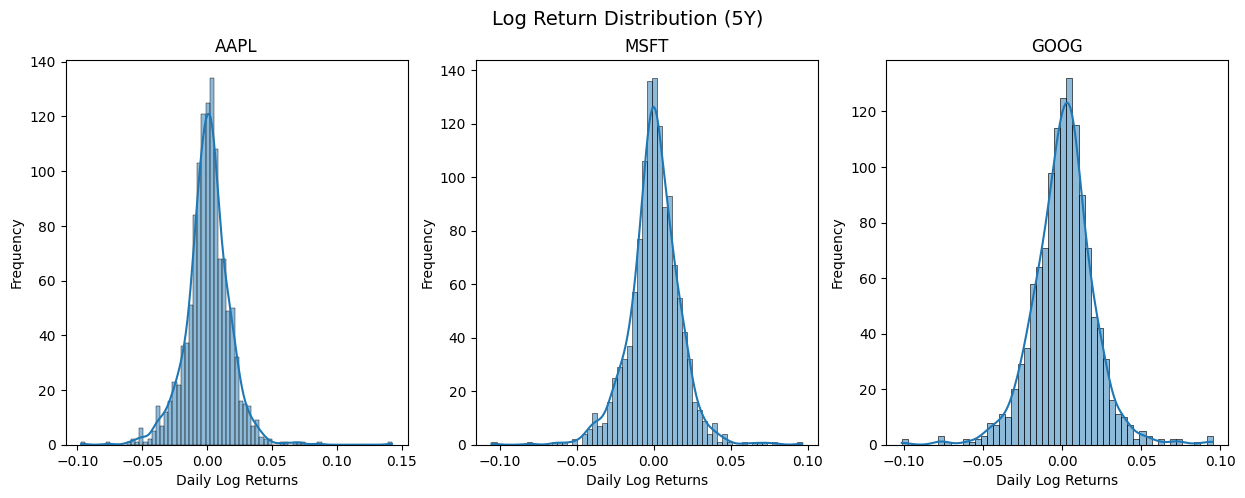

In [76]:
# Building the visualizations for log returns.

fig, axes = plt.subplots(ncols= 3, figsize = (15,5))

fig.suptitle('Log Return Distribution (5Y)', fontsize = 14)

for i, ticker in enumerate(tickers_list):
    sns.histplot(log_returns[ticker], kde = True, ax = axes[i])
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Daily Log Returns')
    axes[i].set_ylabel('Frequency')

Text(0.5, 1.0, 'Log Returns Correlation Matrix (5Y)')

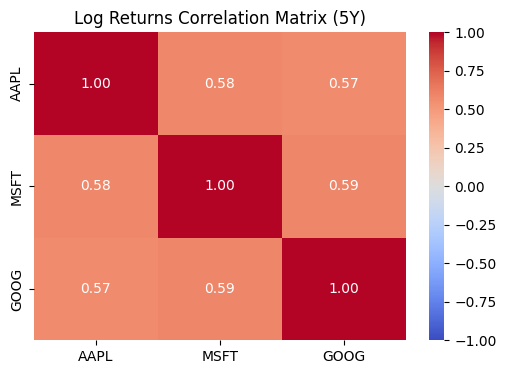

In [77]:
# Building correlation matrix
log_returns_corr = log_returns.corr()

plt.figure(figsize = (6, 4))
sns.heatmap(log_returns_corr, annot = True, vmin = -1, vmax = 1, cmap = 'coolwarm', fmt = '.2f')
plt.title('Log Returns Correlation Matrix (5Y)')